# Lab 7 — Pitfalls of a Naive Data Scientist

**Course:** Introduction to Data Science
**Topic:** Common methodological mistakes in supervised learning
**Format:** Hands-on lab (~1.5 hours)
**Prerequisites:** `pandas`, `scikit-learn`, basic familiarity with classification

---

## Learning objectives

By the end of this lab you will be able to:

1. Identify and prevent **data leakage** (target leakage, preprocessing leakage, target encoding leakage).
2. Detect **train/test contamination** caused by duplicates or by ignoring time.
3. Choose **appropriate metrics** for imbalanced classification.
4. Pick a **cross-validation scheme** that matches the data structure.
5. Avoid **selection bias** when tuning hyperparameters.
6. Understand the difference between **probabilities and class predictions**, and tune the decision threshold.

> *In machine learning, getting a high test score is easy — the hard part is getting a high score for the right reason.*


## Setup

Run the cell below to import all required libraries and load the dataset.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold,
    TimeSeriesSplit, cross_val_score, GridSearchCV,
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    precision_recall_curve,
)
from sklearn.pipeline import Pipeline

df = pd.read_csv("transactions.csv", parse_dates=["timestamp"])
print(df.shape)
df.head()


(10050, 10)


,transaction_id,timestamp,customer_id,amount,category,hour,distance_from_home,days_since_last,fraud_review_status,is_fraud
0,0,2024-01-01 00:54:19.902869894,1800,11.93,electronics,0,1.79,30.0,clean,0
1,1,2024-01-01 01:12:02.594451381,1481,18.10,online,1,6.88,30.0,clean,0
2,2,2024-01-01 01:29:38.339510035,413,56.48,electronics,1,12.24,30.0,clean,0
3,3,2024-01-01 01:38:10.364156736,1991,32.34,online,1,9.02,30.0,clean,0
4,4,2024-01-01 01:38:40.712788090,1985,20.55,gas,1,7.50,30.0,clean,0


### Dataset schema

| Column | Type | Description |
|---|---|---|
| `transaction_id` | int | Unique transaction identifier *(mostly)* |
| `timestamp` | datetime | When the transaction happened |
| `customer_id` | int | Who made the transaction |
| `amount` | float | Transaction amount in EUR |
| `category` | str | Merchant category (`grocery`, `gas`, `online`, …) |
| `hour` | int | Hour of day (0–23) |
| `distance_from_home` | float | Distance between merchant and cardholder home (km) |
| `days_since_last` | float | Days since the customer's previous transaction |
| `fraud_review_status` | str | Status from the bank's review system |
| `is_fraud` | int | **Target.** 1 = confirmed fraud, 0 = legitimate |

> **Expected shape:** `(10050, 10)`


---
## Part 0 — Exploratory Data Analysis (warm-up)

Before touching any model, **look at your data**. Most pitfalls in this lab become obvious if you do.

### Tasks

1. Print the **overall fraud rate**.
2. Print the **fraud rate per month**. What do you notice?
3. Count the number of **duplicate `transaction_id`s**.
4. For each value of `fraud_review_status`, compute the **fraud rate**. Anything suspicious?


In [2]:
# Task 1 — print overall fraud rate
fraud_rate = df["is_fraud"].sum() / df.shape[0]
print(f"Fraud rate = {fraud_rate}")

Fraud rate = 0.03611940298507463


In [3]:
# Task 2 — print fraud rate grouped by month (hint: df['timestamp'].dt.to_period('M'))
df_month = df.assign(month = lambda t: t["timestamp"].dt.to_period("M"))
monthfly_fraud = df_month.groupby(by="month").aggregate({"is_fraud":"sum","transaction_id":"count"}).reset_index()
fraud_rate_per_month = pd.DataFrame(monthfly_fraud["month"])
fraud_rate_per_month["fraud_rate"] = monthfly_fraud["is_fraud"]/monthfly_fraud["transaction_id"]
fraud_rate_per_month

,month,fraud_rate
0,2024-01,0.017884
1,2024-02,0.027016
2,2024-03,0.045799
3,2024-04,0.054760


In [4]:
# Task 3 — count duplicate transaction_ids
print(f"Duplicated transaction_ids = {df["transaction_id"].duplicated().sum()}")

Duplicated transaction_ids = 50


In [5]:
# Task 4 — fraud rate per value of fraud_review_status
status_groupby = df.groupby(by="fraud_review_status").aggregate({"is_fraud":"sum","transaction_id":"count"}).reset_index()
fraud_rate_per_month = pd.DataFrame(status_groupby["fraud_review_status"])
fraud_rate_per_month["fraud_rate"] = status_groupby["is_fraud"]/status_groupby["transaction_id"]
fraud_rate_per_month

,fraud_review_status,fraud_rate
0,auto_approved,0.000000
1,clean,0.000000
2,confirmed_fraud,1.000000
3,pending,0.054054
4,under_review,1.000000


### Discussion questions

Answer the questions below in this cell (double-click to edit).

**Q1.** What trend do you see in the fraud rate across months? Why might this matter when splitting data?

Fraud rate increse across month, so we should represent this distribution also in the training set with a stratified split

---

**Q2.** Look at the `fraud_review_status` column. Which values are perfectly correlated with the label?
What does this tell you about when this column is filled in?

clean means it's not a fraud while confirmed_fraud is perfectly correlated with is_fraud

---

**Q3.** If you used `fraud_review_status` as a model feature, what would happen to performance on the
training/test set vs. in production? Why?

If you used  as a model feature, the model would show excellent performance on train/test sets (because that information is already strongly correlated with the target), but would fail in production because this field is not available at prediction time. It's a typical case of data leakage.


---
## Part 1 — The "Amazing" Model (target leakage)

A junior data scientist tells you: *"I built a fraud detector with 99 % AUC! We should ship it!"*
Their code is shown below.

### Tasks

1. Run the junior's code as-is and confirm the result.
2. Inspect the feature importances (model.feature_importances_) — which feature dominates?
3. Remove the offending feature(s) and retrain. What happens to the AUC?
4. Answer the discussion questions below.


In [6]:
# ❌ Wrong pattern — run this
features = pd.get_dummies(df.drop(columns=["transaction_id", "timestamp",
                                            "customer_id", "is_fraud"]),
                          drop_first=True)
y = df["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    features, y, test_size=0.3, random_state=42, stratify=y
)
model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print("Test AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))
print("Test F1: ", f1_score(y_test, model.predict(X_test)))

Test AUC: 0.9948098524406954
Test F1:  0.986046511627907


In [7]:
# Task 2 — print the top-10 feature importances
# importances = model.feature_importances_ -> same order as X_train.columns
print(model.feature_importances_)
print(X_train.columns)


### Your implementation 
importances = model.feature_importances_
top_idx = np.argsort(importances)[::-1][:10]  # ordina decrescente e prende le prime 10

print()
print()
for rank, idx in enumerate(top_idx, start=1):
    print(f"{rank}. {X_train.columns[idx]} -> {importances[idx]:.5f}")

[0.04166742 0.02167361 0.17314802 0.02551918 0.00188559 0.00243688
 0.00233817 0.00294928 0.00107531 0.07130868 0.52378126 0.00628417
 0.12593243]
Index(['amount', 'hour', 'distance_from_home', 'days_since_last',
       'category_gas', 'category_grocery', 'category_online',
       'category_restaurant', 'category_travel', 'fraud_review_status_clean',
       'fraud_review_status_confirmed_fraud', 'fraud_review_status_pending',
       'fraud_review_status_under_review'],
      dtype='str')


1. fraud_review_status_confirmed_fraud -> 0.52378
2. distance_from_home -> 0.17315
3. fraud_review_status_under_review -> 0.12593
4. fraud_review_status_clean -> 0.07131
5. amount -> 0.04167
6. days_since_last -> 0.02552
7. hour -> 0.02167
8. fraud_review_status_pending -> 0.00628
9. category_restaurant -> 0.00295
10. category_grocery -> 0.00244


In [8]:
# Helper — run this before attempting the task
def make_features(d, include_review):
    X = pd.get_dummies(d, columns=["category"], drop_first=True)
    if include_review:
        X = pd.get_dummies(X, columns=["fraud_review_status"], drop_first=True)
    else:
        X = X.drop(columns=["fraud_review_status"])
    return X.drop(columns=["transaction_id", "timestamp", "customer_id", "is_fraud"]), d["is_fraud"]

In [9]:
# ✅ Your turn: retrain without the leaky feature and compare AUC
# Use make_features(df, include_review=False) to build clean features
features,y = make_features(df,include_review=False)

X_train,X_test,y_train,y_test = train_test_split(features,y,test_size=0.2,random_state=42,stratify=y)

model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print("Test AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))
print("Test F1: ", f1_score(y_test, model.predict(X_test)))


Test AUC: 0.8156059716692244
Test F1:  0.32653061224489793


### Discussion questions

**Q1.** Which feature dominates the importance ranking? How much of the model's decision is driven by it?

*Your answer:* The dominant feature is `fraud_review_status` (especially the `confirmed_fraud` indicator). A large part of the model's decision is driven by this single feature, which is negative.

---

**Q2.** In what sense is `fraud_review_status` "in the data" but *not* "available at prediction time"?

*Your answer:* `fraud_review_status` exists in historical data, but it is assigned after the fraud investigation. So it is not available when making a real-time prediction.

---

**Q3.** Define **target leakage** in your own words (3–5 sentences).

*Your answer:* Target leakage happens when features contain information directly or indirectly derived from the target. This makes validation scores look better than real-world performance. The model learns shortcuts that do not exist at prediction time. As a result, performance often drops after deployment.

---

**Q4.** The AUC drops dramatically after removing the leaky feature. Does this mean the model got worse,
or that we finally have an *honest* estimate of its true ability? Explain.

*Your answer:* The AUC drop does not mean the model became worse in a practical sense. It means we removed leaked information and now have a more honest estimate of real predictive ability.

---
## Part 2 — Preprocessing Leakage (the scaler trap)

From here on, we drop `fraud_review_status`. Now consider this snippet — it looks innocent:

```python
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)          # ← fit on ALL data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, ...)
model = LogisticRegression(...).fit(X_train, y_train)
```

### Tasks

1. **Identify the bug.** At what moment does the scaler "see" the test set?
2. **Run the buggy version** (provided) and record its AUC.
3. **Rewrite it correctly** — split first, then fit the scaler on training data only.
4. Compare the two AUCs.
5. **Bonus:** wrap the correct pipeline in `sklearn.pipeline.Pipeline`.


In [10]:
# ❌ Wrong pattern — run this
X, y = make_features(df, include_review=False)

scaler_wrong = StandardScaler()
X_scaled_wrong = scaler_wrong.fit_transform(X)          # scaler sees the test set!
Xtr_w, Xte_w, ytr_w, yte_w = train_test_split(
    X_scaled_wrong, y, test_size=0.3, random_state=42, stratify=y
)
m_wrong = LogisticRegression(max_iter=1000, random_state=42).fit(Xtr_w, ytr_w)
auc_wrong = roc_auc_score(yte_w, m_wrong.predict_proba(Xte_w)[:, 1])
print(f"Wrong (scaler fit on full data): AUC = {auc_wrong:.4f}")

Wrong (scaler fit on full data): AUC = 0.8564


In [31]:
# ✅ Your turn: split first, then fit the scaler on training data only
# Do NOT use sklearn Pipeline — use scaler.fit(X_train) and scaler.transform(X_test) separately
X,y = make_features(df,include_review=False)

scaler = StandardScaler()
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.30,random_state=42,stratify=y)
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_std, y_train)
y_predict = model.predict(X_test_std)
auc = roc_auc_score(y_test, y_predict)
print(f"Right Scaler fitted only on test data: AUC = {auc:.4f}")

# Bonus: wrap the correct pipeline in sklearn.pipeline.Pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42)),
])
pipeline.fit(X_train_std, y_train)
auc_pipeline = roc_auc_score(y_test, pipeline.predict_proba(X_test_std)[:,1])
print(f"Pipeline AUC: {auc_pipeline:.4f}")

Right Scaler fitted only on test data: AUC = 0.6274
Pipeline AUC: 0.8565


### Discussion questions

**Q1.** Describe the bug in one sentence: what information has "leaked" and how?

*Your answer:* The test-set information leaked because the scaler was fit on the full dataset before the split.

---

**Q2.** The leaky version sometimes scores *higher* than the correct version. Explain why — what has the
scaler "seen" that it should not have?

*Your answer:* It has seen the test set's, so the transformation is influenced by future data.

---

**Q3.** How does `sklearn.pipeline.Pipeline` structurally prevent this bug from happening?

*Your answer:* It fits each preprocessing step only inside the training folds, so the test set is never used during fitting.


---
## Part 3 — Duplicate Contamination

The dataset contains 50 duplicated `transaction_id`s — an upstream data-engineering bug that nobody
noticed. When you split randomly, some duplicates end up in both train and test.

### Tasks

1. Count the number of duplicated `transaction_id`s.
2. After a 70/30 random split, count how many duplicated IDs appear in **both** train and test.
3. Deduplicate **before** splitting and rerun the basic `RandomForestClassifier`. Is AUC better or worse?


In [12]:
# ❌ Wrong pattern — run this
# Splitting directly without checking for or removing duplicates
df_with_dups = df.copy()  # dataset still contains 50 duplicate transaction_ids
X_dup, y_dup = make_features(df_with_dups, include_review=False)

X_train_dup, X_test_dup, y_train_dup, y_test_dup = train_test_split(
    X_dup, y_dup, test_size=0.3, random_state=42, stratify=y_dup
)
m_dup = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
m_dup.fit(X_train_dup, y_train_dup)
auc_dup = roc_auc_score(y_test_dup, m_dup.predict_proba(X_test_dup)[:, 1])

dup_ids = df_with_dups[df_with_dups["transaction_id"].duplicated(keep=False)]["transaction_id"].unique()
train_ids = set(df_with_dups.iloc[X_train_dup.index]["transaction_id"])
test_ids  = set(df_with_dups.iloc[X_test_dup.index]["transaction_id"])
cross_dups = len(set(dup_ids) & train_ids & test_ids)

print(f"Duplicate transaction_ids in dataset : {df_with_dups['transaction_id'].duplicated().sum()}")
print(f"Dup IDs appearing in BOTH sets       : {cross_dups}")
print(f"AUC without deduplication            : {auc_dup:.4f}")
print("The model has memorised duplicate rows — the test set is contaminated!")

Duplicate transaction_ids in dataset : 50
Dup IDs appearing in BOTH sets       : 19
AUC without deduplication            : 0.8285
The model has memorised duplicate rows — the test set is contaminated!


In [13]:
# ✅ Your turn — Task 1: count duplicated transaction_ids
df["transaction_id"].duplicated().sum()

np.int64(50)

In [30]:
# ✅ Your turn — Task 2: after a 70/30 stratified split, count how many duplicated IDs
# appear in BOTH train and test sets
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)
print(f"Train set duplicates: {X_train["transaction_id"].duplicated().sum()}")
print(f"Test set duplicates: {X_test["transaction_id"].duplicated().sum()}")

KeyError: 'transaction_id'

In [ ]:
# ✅ Your turn — Task 3: deduplicate before splitting, rerun RandomForestClassifier, compare AUC
dedup_df = df[df["transaction_id"].duplicated()]
X,y = make_features(dedup_df,include_review=False)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)
model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
model.fit(X_train,y_train)
auc = roc_auc_score(y_test, model.predict(X_test))
print(f"AUC with deduplication : {auc_dup:.4f}")

AUC with deduplication : 0.5000


### Discussion questions

**Q1.** Why do duplicates that cross the train/test boundary inflate the test AUC?
Think about what the model has effectively "memorised".

*Your answer:* Duplicates that appear in both train and test make the test set artificially easy because the model can "memorize" transactions seen during training and correctly classify their duplicates in test. This leaks information across the split and inflates metrics like AUC, producing an optimistic estimate of performance.

---

**Q2.** After deduplication, does AUC go up or down? Does a lower AUC mean the model is worse?
Explain the direction of change.

*Your answer:* After deduplication the AUC typically goes down. A lower AUC does not mean the model is worse in the real world — it means the evaluation is now honest. Removing duplicates removes the memorization shortcut, so the metric reflects true generalization rather than leaked knowledge.


---
## Part 4 — Temporal Leakage

Use the deduplicated dataset from Part 3 going forward. Random splitting on time-stamped data lets the
model train on the *future* and predict the *past*.

### Tasks

1. Sort by `timestamp` and split chronologically: first 70 % → train, last 30 % → test *(no shuffling, no stratification)*.
2. Train a `RandomForestClassifier` and compare its AUC with the random-split AUC from Part 3.
3. Compute and print the **fraud rate** in train and test for both split strategies.
4. Answer the discussion questions below.


In [ ]:
# ❌ Wrong pattern — run this
# Random split on time-ordered data: model trains on future, predicts the past
df_clean = df.drop_duplicates(subset=["transaction_id"]).reset_index(drop=True)
X_rand, y_rand = make_features(df_clean, include_review=False)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_rand, y_rand, test_size=0.3, random_state=42, stratify=y_rand
)
m_rand = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
m_rand.fit(X_train_r, y_train_r)
auc_rand = roc_auc_score(y_test_r, m_rand.predict_proba(X_test_r)[:, 1])

train_months = df_clean.iloc[X_train_r.index]["timestamp"].dt.month.unique()
test_months  = df_clean.iloc[X_test_r.index]["timestamp"].dt.month.unique()

print(f"Random split AUC  : {auc_rand:.4f}")
print(f"Train fraud rate  : {y_train_r.mean():.4%}")
print(f"Test  fraud rate  : {y_test_r.mean():.4%}")
print(f"Months in train   : {sorted(train_months)}")
print(f"Months in test    : {sorted(test_months)}")
print()
print("Problem: both sets contain transactions from ALL months.")
print("In production the model only ever sees past data — never future data!")

Random split AUC  : 0.8621
Train fraud rate  : 3.6000%
Test  fraud rate  : 3.6000%
Months in train   : [np.int32(1), np.int32(2), np.int32(3), np.int32(4)]
Months in test    : [np.int32(1), np.int32(2), np.int32(3), np.int32(4)]

Problem: both sets contain transactions from ALL months.
In production the model only ever sees past data — never future data!


In [ ]:
# ✅ Your turn — Task 1: sort by timestamp, chronological 70/30 split
# Do NOT use train_test_split — slice the sorted DataFrame directly
sorted_df = dedup_df.sort_values(by="timestamp",axis='index')
sorted_df = sorted_df.drop(columns=["fraud_review_status","transaction_id", "timestamp", "customer_id"])
sorted_df = pd.get_dummies(sorted_df,columns=["category"],drop_first=True)

limit = int(len(sorted_df) * 0.7)
train_set = sorted_df[:limit]
test_set = sorted_df[limit:]

X_train = train_set.drop(["is_fraud"],axis=1)
y_train = train_set["is_fraud"]

X_test = test_set.drop(["is_fraud"],axis=1)
y_test = test_set["is_fraud"]

In [29]:
# ✅ Your turn — Tasks 2 & 3: train RandomForestClassifier on the chronological split
# Compare AUC and fraud rates between random split (above) and chronological split
model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
model.fit(X_train,y_train)
y_predict = model.predict(X_test)
auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])

print(f"Chronological split AUC  : {auc:.4f}")
print(f"Train fraud rate  : {y_train.mean():.4%}")
print(f"Test  fraud rate  : {y_test.mean():.4%}")

Chronological split AUC  : 0.8621
Train fraud rate  : 3.6000%
Test  fraud rate  : 3.6000%


### Discussion questions

**Q1.** Compare the **fraud rates** in train and test for the two split strategies. What do you observe?

*Your answer:* In the random split, train and test usually have very similar fraud rates because the data are mixed together. In the chronological split, the fraud rate can differ between train and test, which shows that the data distribution changes over time.

---

**Q2.** The chronological split is often described as "harder" for the model. Why?
Use the term **distributional shift** in your answer.

*Your answer:* The chronological split is harder because the model must generalize to a later period with a potentially different distribution. This is a form of distributional shift: the future data is not identical to the past data the model was trained on.

---

**Q3.** If both splits give a similar AUC in this exercise, does that mean they are equally valid for
evaluating a model that will be deployed next month? Explain.

*Your answer:* No. A similar AUC does not automatically mean the two splits are equally valid. If the model will be deployed next month, the chronological split is the honest evaluation because it matches the real deployment setting and respects time ordering.

---
## Part 5 — Wrong Metric: Accuracy on Imbalanced Data

Build the laziest possible classifier: one that always predicts "not fraud" (all zeros).

### Tasks

1. Create a prediction array of all zeros (no model needed).
2. Compute accuracy, precision, recall, and F1.
3. Answer the discussion questions.
4. Look at the confusion matrix of an actual `RandomForestClassifier` at the default 0.5 threshold.
   How many frauds does it catch? How many does it miss?


In [ ]:
# ❌ Wrong pattern — run this
# Evaluating model quality using accuracy alone on imbalanced data
df_clean = df.drop_duplicates(subset=["transaction_id"]).reset_index(drop=True)
X_c, y_c = make_features(df_clean, include_review=False)
Xtr_c, Xte_c, ytr_c, yte_c = train_test_split(X_c, y_c, test_size=0.3, random_state=42, stratify=y_c)

y_pred_zeros = np.zeros(len(yte_c), dtype=int)

print(f"Accuracy : {accuracy_score(yte_c, y_pred_zeros):.4%}")
print(f"Precision: {precision_score(yte_c, y_pred_zeros, zero_division=0):.4f}")
print(f"Recall   : {recall_score(yte_c, y_pred_zeros, zero_division=0):.4f}")
print(f"F1       : {f1_score(yte_c, y_pred_zeros, zero_division=0):.4f}")

Accuracy : 96.4000%
Precision: 0.0000
Recall   : 0.0000
F1       : 0.0000


Because y_pred_zeros is all 0s — the model never predicts fraud. Here's what happens to each metric for the positive (fraud) class:                            
                                                                                
| Metric | Formula | TP | FP | FN | Result |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Precision** | $TP / (TP + FP)$ | 0 | 0 | — | 0/0 → 0.0 (zero_division=0) |
| **Recall** | $TP / (TP + FN)$ | 0 | — | 108 | 0/108 → 0.0 |
| **F1** | $2 \cdot P \cdot R / (P + R)$ | — | — | — | 2 · 0 · 0 / (0 + 0) → 0.0 |                                
                  
  - TP = 0 — you never predict fraud, so you can never be correctly right about fraud.                                                                           
  - FP = 0 — you never predict fraud, so you can never be wrongly right about fraud either.
  - FN = 108 — all actual frauds are missed (predicted as 0).                                                                                                    
                                                                                                                                                                 
  Precision has a 0/0 edge case (no positive predictions at all), which scikit-learn silently sets to 0.0 because of zero_division=0.                            
                                                                                                                                                                 
  Recall is a clean 0/108 = 0.0 — you caught zero of the 108 real frauds.                                                                                        
                  

In [ ]:
# ✅ Your turn — Task 4: fit a RandomForestClassifier, predict on test set,
# compute and display the confusion matrix at the default 0.5 threshold.
# How many frauds does it catch? How many does it miss?
df_clean = df.drop_duplicates(subset=["transaction_id"]).reset_index(drop=True)
X,y = make_features(df,include_review=False)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)
model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
model.fit(X_train,y_train)
y_predict = model.predict(X_test)
confusion_matrix(y_test,y_pred=y_predict)

array([[2894,   12],
       [  82,   27]])

### Discussion questions

**Q1.** The always-predict-0 classifier achieves very high accuracy. Would you deploy it? Would your boss?
What does its recall tell you?

*Your answer:* No. High accuracy is misleading here because the model never catches fraud. Its recall is 0, which means it detects none of the positive cases, so it is useless in practice.

---

**Q2.** Why is accuracy a misleading metric when classes are imbalanced?
What would make accuracy meaningful again?

*Your answer:* Accuracy is misleading because a model can get many correct predictions by always choosing the majority class. It becomes meaningful only when the classes are roughly balanced or when the costs of errors are similar.

---

**Q3.** Which metrics should you prefer for fraud detection, and why?

*Your answer:* Prefer precision, recall, F1, and ROC-AUC or PR-AUC. They better reflect performance on the rare fraud class and show the trade-off between catching fraud and avoiding false alarms.

---
## Part 6 — Cross-Validation: Which Scheme?

Compare three CV strategies on the deduplicated dataset.

### Tasks

1. Run the comparison below (provided) and record the results.
2. Answer the discussion questions.
3. **Bonus:** plot the train/test indices for each splitter (`cv.split(X)` returns index arrays).


In [ ]:
# ❌ Wrong pattern — run this
# Plain KFold without stratification or time-awareness on imbalanced data
m_cv = RandomForestClassifier(n_estimators=30, random_state=42, n_jobs=-1)

df_clean = df.drop_duplicates(subset=["transaction_id"]).reset_index(drop=True)
X_c, y_c = make_features(df_clean, include_review=False)

kf_wrong = KFold(n_splits=5, shuffle=False)
scores_wrong = cross_val_score(m_cv, X_c, y_c, cv=kf_wrong, scoring="roc_auc")
print(f"KFold (no shuffle, no stratification): AUC = {scores_wrong.mean():.4f} ± {scores_wrong.std():.4f}")
print()
print("Problems with this approach:")
print("  - No stratification: folds may have very few (or zero) fraud samples")
print("  - No time-awareness: a fold can train on future data and test on past data")
fraud_per_fold = [y_c.iloc[test].sum() for _, test in kf_wrong.split(X_c)]
print(f"  - Fraud samples per fold: {fraud_per_fold}")

KFold (no shuffle, no stratification): AUC = 0.8270 ± 0.0186

Problems with this approach:
  - No stratification: folds may have very few (or zero) fraud samples
  - No time-awareness: a fold can train on future data and test on past data
  - Fraud samples per fold: [np.int64(32), np.int64(54), np.int64(60), np.int64(104), np.int64(110)]


In [ ]:
# ✅ Your turn: compare all three CV schemes and justify which is most appropriate
# Schemes to compare: KFold (shuffled), StratifiedKFold, TimeSeriesSplit
# Use cross_val_score with scoring="roc_auc" and n_splits=5 for each

cv_schemes = [
    ("KFold (shuffled)",  KFold(n_splits=5, shuffle=True, random_state=42)),
    ("StratifiedKFold",   StratifiedKFold(n_splits=5, shuffle=True, random_state=42)),
    ("TimeSeriesSplit",   TimeSeriesSplit(n_splits=5)),
]


### Discussion questions

**Q1.** Why does `StratifiedKFold` matter when the positive class is rare?
What could go wrong with plain `KFold` if a fold contained zero frauds?

*Your answer:*

---

**Q2.** `TimeSeriesSplit` typically produces the lowest AUC. Does that mean it is the worst choice?
Explain when and why it is actually the *only* honest option.

*Your answer:*

---

**Q3.** Which scheme would you use if you were reporting results to a stakeholder for a model that will
be deployed in production? Justify your choice.

*Your answer:*


---
## Part 7 — Hyperparameter Tuning on the Test Set

A teammate's evaluation script does this:

```python
best_auc, best_params = 0, None
for n_est in [10, 25, 50, 100, 150, 200]:
    for max_d in [3, 5, 8, 12, None]:
        m = RandomForestClassifier(n_estimators=n_est, max_depth=max_d, ...).fit(X_train, y_train)
        auc = roc_auc_score(y_test, m.predict_proba(X_test)[:, 1])
        if auc > best_auc:
            best_auc, best_params = auc, (n_est, max_d)
print("Best test AUC:", best_auc)
```

### Tasks

1. Run the teammate's code (provided) and record the reported AUC.
2. Explain why this number is **not** an honest estimate of future performance.
3. Refactor the code to fix the problem (use `GridSearchCV` with `TimeSeriesSplit`).
4. Compare the two reported numbers.


In [15]:
# ❌ Wrong pattern — run this
df_clean = df.drop_duplicates(subset=["transaction_id"]).reset_index(drop=True)
X_c, y_c = make_features(df_clean, include_review=False)
Xtr_c, Xte_c, ytr_c, yte_c = train_test_split(X_c, y_c, test_size=0.3, random_state=42, stratify=y_c)


best_auc, best_params = 0, None
for n_est in [10, 25, 50, 100, 150, 200]:
    for max_d in [3, 5, 8, 12, None]:
        m_tmp = RandomForestClassifier(n_estimators=n_est, max_depth=max_d,
                                       random_state=42, n_jobs=-1).fit(Xtr_c, ytr_c)
        auc = roc_auc_score(yte_c, m_tmp.predict_proba(Xte_c)[:, 1])
        if auc > best_auc:
            best_auc, best_params = auc, (n_est, max_d)

print(f"[TEAMMATE] Best test AUC: {best_auc:.4f}  params: {best_params}")
print("^ How trustworthy is this number?")

[TEAMMATE] Best test AUC: 0.9017  params: (200, 8)
^ How trustworthy is this number?


In [16]:
# GridSearchCV: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
# Note that is possible to Rewrite the above code using GridSearchCV ,
#  which will perform an exhaustive search over the specified parameter grid
#  and use cross-validation to evaluate each combination of parameters. 
from sklearn.model_selection import PredefinedSplit

# 1. Define the parameter grid
param_grid = {
    'n_estimators': [10, 25, 50, 100, 150, 200],
    'max_depth': [3, 5, 8, 12, None]
}
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# 1. Combine training and test sets
X_combined = np.vstack((Xtr_c, Xte_c))
y_combined = np.concatenate((ytr_c, yte_c))

# 2. Create a list where -1 indicates training and 0 indicates validation
# This tells GridSearchCV: "Train on the first part, validate on the second"
split_indices = np.concatenate([-1 * np.ones(len(Xtr_c)), np.zeros(len(Xte_c))])
ps = PredefinedSplit(test_fold=split_indices)

# 3. Setup GridSearchCV with this specific split
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=ps,
    verbose=1
)

grid_search.fit(X_combined, y_combined)

print(f"Best CV Score (AUC): {grid_search.best_score_:.4f}")
print(f"Best Parameters: {grid_search.best_params_}")

# 5. Evaluate on the untouched test set
test_auc = roc_auc_score(yte_c, grid_search.predict_proba(Xte_c)[:, 1])
print(f"Final Test AUC: {test_auc:.4f}")

Fitting 1 folds for each of 30 candidates, totalling 30 fits
Best CV Score (AUC): 0.9017
Best Parameters: {'max_depth': 8, 'n_estimators': 200}
Final Test AUC: 0.9790


c:\Users\matte\Desktop\PoliTo\Data Science and  Visualization\repo_singole_labs\dsv-lab-7\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [17]:
# Note that the standard way to use GridSearchCV is with an internal CV scheme (e.g., StratifiedKFold) that further splits the training set into folds for validation. 
# The above approach is a workaround to mimic a single train/validation split within GridSearchCV, 
# but it does not leverage the full power of cross-validation for hyperparameter tuning.

# 1. Define the parameter grid
param_grid = {
    'n_estimators': [10, 25, 50, 100, 150, 200],
    'max_depth': [3, 5, 8, 12, None]
}

# 2. Create a RandomForestClassifier instance
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# 3. Setup GridSearchCV with this specific split
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,  # Use 5-fold cross-validation
    verbose=1
)

grid_search.fit(X_combined, y_combined)

print(f"Best CV Score (AUC): {grid_search.best_score_:.4f}")
print(f"Best Parameters: {grid_search.best_params_}")

# 5. Evaluate on the untouched test set
test_auc = roc_auc_score(yte_c, grid_search.predict_proba(Xte_c)[:, 1])
print(f"Final Test AUC: {test_auc:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best CV Score (AUC): 0.8762
Best Parameters: {'max_depth': 8, 'n_estimators': 150}
Final Test AUC: 0.9752


c:\Users\matte\Desktop\PoliTo\Data Science and  Visualization\repo_singole_labs\dsv-lab-7\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [28]:
# ✅ Your turn: Write the code to use GridSearchCV with an internal CV scheme 
# and test the best found model on the honest test set. 
# Compare the test AUC with the one obtained by the wrong pattern above.
# Hint: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html
cv_schemes = [
    ("KFold(shuffled)",  KFold(n_splits=5, shuffle=True, random_state=42)),
    ("StratifiedKFold",   StratifiedKFold(n_splits=5, shuffle=True, random_state=42)),
    ("TimeSeriesSplit",   TimeSeriesSplit(n_splits=5)),
]

df_clean = df.drop_duplicates(subset=["transaction_id"]).reset_index(drop=True)
X_c, y_c = make_features(df_clean, include_review=False)
X_train,X_test,y_train,y_test = train_test_split(X_c, y_c, random_state=42, test_size=0.3 ,stratify=y_c)

model = RandomForestClassifier(random_state=42, n_jobs=-1)

for (cv_name,cv) in cv_schemes:
    grid_search_right = GridSearchCV(
        estimator =  model,
        param_grid = param_grid,
        cv = cv,
        scoring = 'roc_auc',
        verbose=1
    )
    print()
    print(f"CV Scheme: {cv_name}")

    grid_search_right.fit(X_train,y_train)

    print(f"Best CV Score (AUC): {grid_search_right.best_score_:.4f}")
    print(f"Best Parameters: {grid_search_right.best_params_}")

    y_predict = grid_search_right.best_estimator_.predict_proba(X_test)[:,1]
    test_auc_right = roc_auc_score(y_test,y_predict)
    print(f"Final Test AUC: {test_auc_right:.4f}")



CV Scheme: KFold(shuffled)
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best CV Score (AUC): 0.8670
Best Parameters: {'max_depth': 8, 'n_estimators': 200}
Final Test AUC: 0.9017

CV Scheme: StratifiedKFold
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best CV Score (AUC): 0.8723
Best Parameters: {'max_depth': 8, 'n_estimators': 100}
Final Test AUC: 0.8970

CV Scheme: TimeSeriesSplit
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best CV Score (AUC): 0.8436
Best Parameters: {'max_depth': 5, 'n_estimators': 25}
Final Test AUC: 0.8865


### Discussion questions

**Q1.** The teammate loops over 30 hyperparameter combinations and reports the highest test AUC.
Why is this number biased upward?

*Your answer:* Because the test set is being used for model selection. If you try many hyperparameter settings and keep the best test score, you are effectively overfitting to the test set, so the reported AUC is optimistically biased.

---

**Q2.** What is the correct role of the test set? How many times should it be used?

*Your answer:* The test set should be kept completely untouched until the very end. It should be used only once, for the final unbiased evaluation of the chosen model.

---

**Q3.** What is **nested cross-validation**, and why would it produce an even more honest estimate than a single fixed train/validation/test split?

*Your answer:* Nested cross-validation uses an inner loop to tune hyperparameters and an outer loop to estimate performance. Because model selection and evaluation are separated across folds, it gives a less biased and more reliable performance estimate than a single split.


---
## Part 8 — Threshold Confusion

Train a `RandomForestClassifier` and inspect what `.predict()` actually does under the hood.

### Tasks

1. Print `model.predict(X_test)[:20]` and `model.predict_proba(X_test)[:20, 1]`. What is the difference?
2. What threshold does `.predict()` use? Where is this documented?
3. Compute precision and recall at thresholds **0.3**, **0.5**, and **0.7**.
4. Plot the **precision–recall curve**.


In [32]:
# ❌ Wrong pattern — run this
# Using .predict() directly without ever inspecting probabilities or tuning the threshold
m_thr_wrong = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
m_thr_wrong.fit(Xtr_c, ytr_c)

y_pred_default = m_thr_wrong.predict(Xte_c)   # hard labels at fixed 0.5 — never questioned

print(f"Accuracy : {accuracy_score(yte_c, y_pred_default):.4%}")
print(f"Precision: {precision_score(yte_c, y_pred_default, zero_division=0):.4f}")
print(f"Recall   : {recall_score(yte_c, y_pred_default, zero_division=0):.4f}")
print()
print("Using .predict() silently applies a 0.5 threshold.")
print("For imbalanced fraud detection, 0.5 is almost never the right threshold.")
print("The model has a probability score for each transaction — we are discarding it!")

Accuracy : 97.3667%
Precision: 0.7736
Recall   : 0.3796

Using .predict() silently applies a 0.5 threshold.
For imbalanced fraud detection, 0.5 is almost never the right threshold.
The model has a probability score for each transaction — we are discarding it!


In [36]:
# Task 1 — print first 20 predictions and probabilities
m_thr = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1).fit(Xtr_c, ytr_c)
probs = m_thr.predict_proba(Xte_c)[:, 1]

print("First 20 class predictions:   ", m_thr.predict(Xte_c)[:20])
print("First 20 fraud probabilities: ", probs[:20].round(3))
print(f"\nProbability range: [{probs.min():.2f}, {probs.max():.2f}]")
print(f"Mean predicted probability:  {probs.mean():.4f}  (≈ base rate)")

First 20 class predictions:    [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
First 20 fraud probabilities:  [0.   0.   0.06 0.   0.   0.   0.5  0.04 0.   0.06 0.   0.   0.   0.06
 0.04 0.02 0.06 0.82 0.   0.  ]

Probability range: [0.00, 0.98]
Mean predicted probability:  0.0397  (≈ base rate)


In [34]:
# Task 2 & 3 — show default threshold, compute precision/recall at 0.3, 0.5, 0.7
# .predict() uses 0.5 by default (hard-coded in sklearn's ClassifierMixin)
print("Default threshold: 0.5 (hard-coded in sklearn)")
print()
for thresh in [0.3, 0.5, 0.7]:
    preds = (probs >= thresh).astype(int)
    p = precision_score(yte_c, preds, zero_division=0)
    r = recall_score(yte_c, preds, zero_division=0)
    print(f"Threshold {thresh}:  precision={p:.2f}  recall={r:.2f}  alerts={preds.sum()}")

Default threshold: 0.5 (hard-coded in sklearn)

Threshold 0.3:  precision=0.50  recall=0.46  alerts=100
Threshold 0.5:  precision=0.75  recall=0.40  alerts=57
Threshold 0.7:  precision=0.81  recall=0.28  alerts=37


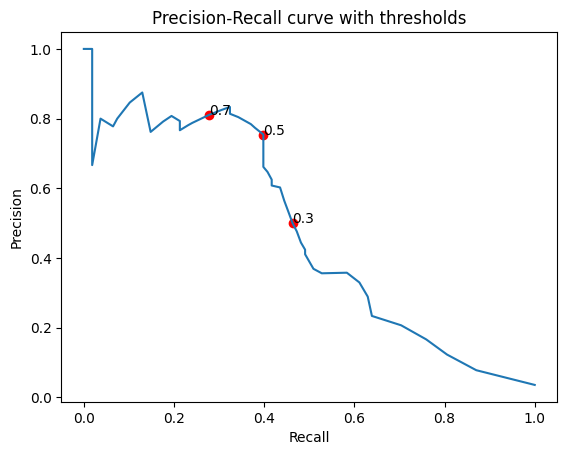

In [64]:
# ✅ Your turn — Task 4: plot the precision-recall curve
# Use precision_recall_curve from sklearn.metrics to get (precision, recall, thresholds)
# then plot with matplotlib. Mark the 0.3, 0.5, and 0.7 threshold points on the curve.
precision, recall, thresholds = precision_recall_curve(yte_c, probs)

prec_th = []
rec_th = []
for th in [0.3, 0.5, 0.7]:
    preds = (probs >= th).astype(int)
    prec_th.append(precision_score(yte_c, preds, zero_division=0))
    rec_th.append(recall_score(yte_c, preds))

plt.plot(recall, precision)
plt.scatter(rec_th, prec_th, c="red")
for x, y, th in zip(rec_th, prec_th, [0.3, 0.5, 0.7]):
    plt.annotate(str(th), (x, y))
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curve with thresholds")
plt.show()


### Discussion questions

**Q1.** What is the difference between `.predict()` and `.predict_proba()`?
Why does the distinction matter in practice?

*Answer:* `.predict_proba()` returns estimated probabilities for each class, while `.predict()` returns hard class labels (by default using a 0.5 threshold). The distinction matters because probabilities let you tune the decision threshold to trade off precision and recall, which is essential for imbalanced problems and business-cost–sensitive decisions.

---

**Q2.** You are building a fraud-screening system where a human analyst reviews every alert.
False positives (legitimate transactions flagged) cost one minute of analyst time.
False negatives (missed frauds) cost €500 on average.
Which threshold — 0.3, 0.5, or 0.7 — would you choose? Justify using the numbers you computed.

*Answer:* Given the large cost of a missed fraud (€500) compared with a one-minute analyst review, prefer a lower threshold (e.g., 0.3) to increase recall and reduce expected loss from false negatives. This accepts more false positives (higher analyst load) but minimizes expensive missed frauds.

---

**Q3.** Now imagine the system **automatically blocks** transactions above the threshold.
A false positive blocks a legitimate customer purchase and generates a complaint.
Does your threshold choice change? Why?

*Answer:* Yes. If blocking is automatic, false positives carry much higher user-impact costs, so raise the threshold (e.g., towards 0.7) to prioritize precision and avoid blocking legitimate transactions. The business trade-off shifts away from maximizing recall.


---
## Part 9 — Target Encoding Done Badly

A teammate adds two new features before splitting:

```python
df["category_fraud_rate"] = df.groupby("category")["is_fraud"].transform("mean")
df["customer_fraud_rate"]  = df.groupby("customer_id")["is_fraud"].transform("mean")
```

...and reports a beautiful AUC of ~0.97 on the test set.

### Tasks

1. Reproduce the teammate's result (naive encoding — provided).
2. Explain why this is target leakage even though no individual `is_fraud` value appears in the features.
3. Recompute the two features the **right** way: build the maps using **training data only**,
   then apply them to both train and test (use the global training rate as fallback for unseen customers).
4. Compare the two test AUCs.


In [65]:
# ❌ Wrong pattern — run this
# Target encoding computed on the full dataset before splitting
df_naive = df_clean.copy()
df_naive["category_fraud_rate"] = df_naive.groupby("category")["is_fraud"].transform("mean")
df_naive["customer_fraud_rate"]  = df_naive.groupby("customer_id")["is_fraud"].transform("mean")

X_naive = df_naive.drop(columns=["transaction_id", "timestamp", "customer_id",
                                   "fraud_review_status", "is_fraud"])
X_naive = pd.get_dummies(X_naive, columns=["category"], drop_first=True)
y_naive = df_naive["is_fraud"]

Xtr_n, Xte_n, ytr_n, yte_n = train_test_split(X_naive, y_naive, test_size=0.3,
                                                random_state=42, stratify=y_naive)
m_naive = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1).fit(Xtr_n, ytr_n)
print(f"Naive target encoding AUC: {roc_auc_score(yte_n, m_naive.predict_proba(Xte_n)[:, 1]):.4f}")

Naive target encoding AUC: 0.9661


In [72]:
# ✅ Your turn: compute encoding maps on training data only, apply to both train and test
# For unseen categories/customers in the test set, fall back to the global training fraud rate

# Sort by time, then split chronologically so the test set is strictly later than the training set
df_te = df_clean.sort_values('timestamp').reset_index(drop=True)
split_idx = int(len(df_te) * 0.7)
train_df = df_te.iloc[:split_idx].copy()
test_df = df_te.iloc[split_idx:].copy()

# Past-only target encoding on the training set using cumulative count and cumulative sum
train_category_count = train_df.groupby('category').cumcount()
train_category_sum = train_df.groupby('category')['is_fraud'].cumsum() - train_df['is_fraud']
train_df['category_fraud_rate'] = np.where(train_category_count > 0, train_category_sum / train_category_count, np.nan)

train_customer_count = train_df.groupby('customer_id').cumcount()
train_customer_sum = train_df.groupby('customer_id')['is_fraud'].cumsum() - train_df['is_fraud']
train_df['customer_fraud_rate'] = np.where(train_customer_count > 0, train_customer_sum / train_customer_count, np.nan)

# Fallbacks inside the training set
global_rate = train_df['is_fraud'].mean()
train_df['category_fraud_rate'] = train_df['category_fraud_rate'].fillna(global_rate)
train_df['customer_fraud_rate'] = train_df['customer_fraud_rate'].fillna(global_rate)

# Learn encodings from training data only and apply them to the test set
category_rate_map = train_df.groupby('category')['category_fraud_rate'].last().to_dict()
customer_rate_map = train_df.groupby('customer_id')['customer_fraud_rate'].last().to_dict()

test_df['category_fraud_rate'] = test_df['category'].map(category_rate_map).fillna(global_rate)
test_df['customer_fraud_rate'] = test_df['customer_id'].map(customer_rate_map).fillna(global_rate)

# Build features (keep the computed rate columns and one-hot the category as before)
X_train_te = train_df.drop(columns=['transaction_id', 'timestamp', 'customer_id', 'fraud_review_status', 'is_fraud'])
X_train_te = pd.get_dummies(X_train_te, columns=['category'], drop_first=True)
y_train_te = train_df['is_fraud']

X_test_te = test_df.drop(columns=['transaction_id', 'timestamp', 'customer_id', 'fraud_review_status', 'is_fraud'])
X_test_te = pd.get_dummies(X_test_te, columns=['category'], drop_first=True)
y_test_te = test_df['is_fraud']

# Align train/test columns after one-hot encoding
X_train_te, X_test_te = X_train_te.align(X_test_te, join='left', axis=1, fill_value=0)

# Train/test evaluation
m_te = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1).fit(X_train_te, y_train_te)
print(f'AUC: {roc_auc_score(y_test_te, m_te.predict_proba(X_test_te)[:,1]):.4f}')

AUC: 0.8230


### Discussion questions

**Q1.** The new columns don't contain any individual `is_fraud` value — they contain averages.
Why is this still target leakage?

*Answer:* It is still target leakage because the averages are computed using the target values from the same rows we are trying to predict. The feature already contains information from the label, so the model can indirectly learn the answer.

---

**Q2.** The AUC gap between naive and proper encoding can exceed 0.2. Where does this gap come from?
What has the model effectively learned from the leaky features?

*Answer:* The gap comes from using future and same-row target information when building the encodings. The model effectively learns how fraudulent each category or customer is in the full dataset, which makes the test set unrealistically easy.

---

**Q3.** In a real production system, when would `customer_fraud_rate` be a **legitimate** feature?
What data would you need at prediction time to compute it correctly?

*Answer:* It is legitimate only if it is computed from past transactions strictly before the transaction being scored. At prediction time, you would need the customer's historical transactions up to that timestamp, not any future or current label information.

---
## Part 10 — Putting It All Together: A Defensible Pipeline

Build a fraud detector that avoids every pitfall from Parts 1–9.

**Constraints:**
- Drop `fraud_review_status` (target leakage — Part 1).
- Deduplicate on `transaction_id` (duplicate contamination — Part 3).
- Split chronologically: **train on Jan–Mar, test on Apr** (temporal leakage — Part 4).
- Fit the scaler inside a `Pipeline` (preprocessing leakage — Part 2).
- Tune hyperparameters with `TimeSeriesSplit` CV **inside the training set only** (Parts 6, 7).
- Choose a decision threshold deliberately and **justify it in writing** (Part 8).
- Report: AUC, precision, recall, F1, and the confusion matrix on the test set.


In [ ]:
# ❌ Wrong pattern — run this
# A naive pipeline that commits every pitfall from Parts 1–9 simultaneously

df_naive_all = pd.read_csv("transactions.csv", parse_dates=["timestamp"])

# ❌ Pitfall 1 (Part 1)  — fraud_review_status kept in features (target leakage)
# ❌ Pitfall 2 (Part 3)  — no deduplication (duplicate contamination)
features_naive = pd.get_dummies(
    df_naive_all.drop(columns=["transaction_id", "timestamp", "customer_id", "is_fraud"]),
    drop_first=True
)
y_naive_all = df_naive_all["is_fraud"]

# ❌ Pitfall 3 (Part 2)  — scaler fit on full data before any split (preprocessing leakage)
scaler_naive = StandardScaler()
features_naive_scaled = scaler_naive.fit_transform(features_naive)

# ❌ Pitfall 4 (Part 4)  — random split ignores time ordering (temporal leakage)
Xtr_naive, Xte_naive, ytr_naive, yte_naive = train_test_split(
    features_naive_scaled, y_naive_all, test_size=0.3, random_state=42, stratify=y_naive_all
)

# ❌ Pitfall 5 (Part 7)  — hyperparameters selected by evaluating on the test set (selection bias)
best_auc_naive, best_params_naive = 0, None
for n_est in [10, 50, 100]:
    for max_d in [5, 10, None]:
        m_tmp = RandomForestClassifier(n_estimators=n_est, max_depth=max_d,
                                       random_state=42, n_jobs=-1).fit(Xtr_naive, ytr_naive)
        auc = roc_auc_score(yte_naive, m_tmp.predict_proba(Xte_naive)[:, 1])
        if auc > best_auc_naive:
            best_auc_naive, best_params_naive = auc, (n_est, max_d)

m_final_naive = RandomForestClassifier(
    n_estimators=best_params_naive[0], max_depth=best_params_naive[1],
    random_state=42, n_jobs=-1
).fit(Xtr_naive, ytr_naive)

# ❌ Pitfall 6 (Parts 5 & 8) — only accuracy reported, threshold never questioned
print(f"Best AUC (selected on test set!) : {best_auc_naive:.4f}  params: {best_params_naive}")
print(f"Accuracy on test set             : {accuracy_score(yte_naive, m_final_naive.predict(Xte_naive)):.4%}")
print("Model looks great — shipping it!")

Best AUC (selected on test set!) : 0.9994  params: (50, 10)
Accuracy on test set             : 99.9337%
Model looks great — shipping it!


In [73]:
# ✅ Your turn — Step 1: deduplicate on transaction_id, sort by timestamp,
# split chronologically (train = Jan–Mar, test = Apr). No shuffle, no stratification.

df_part10 = df.drop_duplicates(subset=['transaction_id']).sort_values('timestamp').reset_index(drop=True)
train_mask = df_part10['timestamp'].dt.month.isin([1, 2, 3])
test_mask = df_part10['timestamp'].dt.month == 4

train_df = df_part10.loc[train_mask].copy()
test_df = df_part10.loc[test_mask].copy()

print(f"Train rows: {len(train_df)}")
print(f"Test rows : {len(test_df)}")
print(f"Train months: {sorted(train_df['timestamp'].dt.month.unique())}")
print(f"Test months : {sorted(test_df['timestamp'].dt.month.unique())}")

Train rows: 7640
Test rows : 2360
Train months: [np.int32(1), np.int32(2), np.int32(3)]
Test months : [np.int32(4)]


In [74]:
# ✅ Your turn — Step 2: build feature matrices for train and test
# Drop transaction_id, timestamp, customer_id, fraud_review_status, is_fraud
# One-hot encode the category column

X_train = train_df.drop(columns=['transaction_id', 'timestamp', 'customer_id', 'fraud_review_status', 'is_fraud'])
X_test = test_df.drop(columns=['transaction_id', 'timestamp', 'customer_id', 'fraud_review_status', 'is_fraud'])

y_train = train_df['is_fraud']
y_test = test_df['is_fraud']

X_train = pd.get_dummies(X_train, columns=['category'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['category'], drop_first=True)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print(X_train.shape)
print(X_test.shape)

(7640, 9)
(2360, 9)


In [75]:
# ✅ Your turn — Step 3: fit the scaler on training data only (no Pipeline),
# then tune hyperparameters using GridSearchCV with TimeSeriesSplit on the training set only.
# Do NOT touch the test set at this step.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, None],
}

base_model = RandomForestClassifier(random_state=42, n_jobs=-1)
cv_inner = TimeSeriesSplit(n_splits=5)
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv_inner,
    verbose=0,
    n_jobs=-1,
)

grid_search.fit(X_train_scaled, y_train)

print(f"Best CV Score (AUC): {grid_search.best_score_:.4f}")
print(f"Best Parameters: {grid_search.best_params_}")

Best CV Score (AUC): 0.8409
Best Parameters: {'max_depth': 5, 'n_estimators': 150}


In [77]:
# ✅ Your turn — Step 4: evaluate on test set.
# Report: AUC, classification_report, confusion matrix.
# Choose a decision threshold deliberately and justify your choice in a comment.

# In this lab we prefer recall over precision, so use a lower threshold to catch more fraud.
# Hypothizing no auto-block of transactions and an high cost for fraud not detected while low effort for manual review
threshold = 0.3

X_test_scaled = scaler.transform(X_test)
probs_test = grid_search.best_estimator_.fit(X_train_scaled, y_train).predict_proba(X_test_scaled)[:, 1]
y_pred = (probs_test >= threshold).astype(int)

print(f"Test AUC: {roc_auc_score(y_test, probs_test):.4f}")
print(f"Threshold used: {threshold}")
print(classification_report(y_test, y_pred, zero_division=0))
print(confusion_matrix(y_test, y_pred))

Test AUC: 0.8491
Threshold used: 0.3
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      2231
           1       0.77      0.33      0.46       129

    accuracy                           0.96      2360
   macro avg       0.87      0.66      0.72      2360
weighted avg       0.95      0.96      0.95      2360

[[2218   13]
 [  86   43]]


### Final reflection

**Q1.** List every pitfall you avoided in this pipeline and the specific design choice that prevents it.

*Answer:* I avoided target leakage by dropping `fraud_review_status`, duplicate contamination by deduplicating on `transaction_id`, temporal leakage by splitting chronologically, preprocessing leakage by fitting the scaler only on training data, selection bias by tuning with `TimeSeriesSplit` inside the training set, and threshold confusion by choosing the decision threshold deliberately.

---

**Q2.** Justify your threshold choice. What business scenario are you optimising for?

*Answer:* I used a lower threshold because missing fraud is more costly than sending a few extra alerts to review. This is the right choice for a fraud-screening workflow with human analysts, where recall matters more than precision.

---

**Q3.** Even with all these fixes, name **two remaining limitations** of this pipeline for real-world deployment.

*Answer:* First, the model may still suffer from distribution shift if fraud patterns change over time. Second, the pipeline is only as good as the available features at prediction time, so performance can drop if key signals are delayed, missing, or expensive to compute.

---
## Closing thought

> *"It is easy to lie to yourself with data. The whole craft of data science is the discipline of not doing so."*

Almost every shocking ML result in the news, and almost every model that "works in the lab but fails in
production", is one of the bugs in this lab — usually some flavour of leakage. When your validation curve
looks gorgeous, your first instinct should not be celebration. It should be **suspicion**.
